# FinSightAI
## Ver más allá de tus finanzas

### Pipeline Integral de Ciencia de Datos

**Proyecto desarrollado para el Hackathon Oracle Next Education (ONE) y No Country**

**Equipo:** TwentyNine Devs (G9 LATAM Team 29)

---

## Objetivo

**FinSightAI** es una plataforma de análisis financiero inteligente diseñada para ayudar a los usuarios a comprender mejor sus hábitos de consumo y tomar decisiones financieras más informadas mediante el uso de Ciencia de Datos y Machine Learning.

El proyecto implementa un pipeline integral que abarca desde la exploración y preparación de datos hasta el entrenamiento de modelos predictivos, la generación de recomendaciones personalizadas y la exposición de los modelos mediante un microservicio desarrollado con FastAPI para su integración con un backend en Spring Boot.

Este notebook documenta y ejecuta de principio a fin el flujo completo de Ciencia de Datos desarrollado para el proyecto.

---

## Objetivos del notebook

- Explorar y comprender la estructura de los datos.
- Limpiar y preparar la información para su utilización en modelos de Machine Learning.
- Procesar variables financieras y textuales.
- Diseñar e implementar técnicas de ingeniería de atributos.
- Entrenar un modelo para la clasificación automática de categorías de gastos.
- Entrenar un modelo para la clasificación del perfil financiero de los usuarios.
- Evaluar ambos modelos mediante métricas de rendimiento y validación cruzada.
- Analizar la capacidad de generalización del clasificador de gastos utilizando una evaluación agrupada por descripción.
- Interpretar las variables y características con mayor influencia en las predicciones.
- Serializar los modelos entrenados y los artefactos necesarios para su reutilización.
- Simular procesos de inferencia y generar respuestas estructuradas en formato JSON para su integración con el backend.

---

## Alcance

El resultado de este notebook constituye la base del módulo de Inteligencia Artificial de **FinSightAI**, proporcionando los modelos de Machine Learning que posteriormente son consumidos por un microservicio desarrollado con FastAPI. Dicho servicio permite que aplicaciones externas, como el backend implementado en Spring Boot y el frontend del proyecto, obtengan clasificaciones, perfiles financieros y recomendaciones mediante una API REST.

---

> **Nota:** Los datos utilizados son sintéticos y fueron diseñados para validar el funcionamiento del pipeline de Ciencia de Datos y la arquitectura de integración. El flujo implementado está preparado para procesar datos reales utilizando el mismo contrato de entrada; sin embargo, antes de un despliegue en producción, los modelos deberán reentrenarse y validarse utilizando información financiera real y representativa.

**Versión del notebook:** 3.2.0

**Última actualización:** Julio 2026

## 1. Importación de librerías y configuración

In [35]:
from pathlib import Path
import json
import re
import unicodedata
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
)
from sklearn.model_selection import (
    StratifiedGroupKFold,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
DATA_DIR = Path(".")
ARTIFACTS_DIR = Path("artefactos_financeai_v3")
MODELS_DIR = ARTIFACTS_DIR / "modelos"
PROCESSED_DIR = ARTIFACTS_DIR / "datos_procesados"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

## 2. Carga reproducible de los datasets

La celda busca primero los CSV en el directorio actual. Si se ejecuta en Google Colab y no los encuentra, solicita su carga una sola vez.

In [36]:
def localizar_o_subir_csv(nombre_archivo: str) -> Path:
    rutas_posibles = [
        Path(nombre_archivo),
        Path("/content") / nombre_archivo,
        Path("/mnt/data") / nombre_archivo,
    ]

    for ruta in rutas_posibles:
        if ruta.exists():
            return ruta

    try:
        from google.colab import files
        print(f"No se encontró {nombre_archivo}. Seleccioná el archivo para subirlo.")
        archivos = files.upload()
        if nombre_archivo not in archivos:
            raise FileNotFoundError(
                f"Se esperaba el archivo {nombre_archivo}, pero no fue cargado."
            )
        return Path(nombre_archivo)
    except ImportError as exc:
        raise FileNotFoundError(
            f"No se encontró {nombre_archivo}. Colocalo junto al notebook."
        ) from exc


RUTA_USUARIOS = localizar_o_subir_csv("usuarios_sinteticos.csv")
RUTA_TRANSACCIONES = localizar_o_subir_csv("transacciones_sinteticas.csv")

usuarios_raw = pd.read_csv(RUTA_USUARIOS)
transacciones_raw = pd.read_csv(RUTA_TRANSACCIONES)

print("Usuarios:", usuarios_raw.shape)
print("Transacciones:", transacciones_raw.shape)

Usuarios: (100, 9)
Transacciones: (4500, 9)


# 3. Exploración y calidad de datos

In [37]:
display(usuarios_raw.head())
display(transacciones_raw.head())

print("\nColumnas de usuarios:")
print(usuarios_raw.columns.tolist())

print("\nColumnas de transacciones:")
print(transacciones_raw.columns.tolist())

,usuario_id,ingreso_mensual,deuda_mensual,nivel_endeudamiento,gasto_mensual_promedio,ahorro_mensual_estimado,porcentaje_gastos_ingreso,frecuencia_ahorro,perfil_financiero
0,USR0001,"4,379.0900",832.9000,19.0200,"1,114.3100","2,431.8800",44.4700,Alta,Saludable
1,USR0002,"6,100.1400",968.0900,15.8700,"1,013.9600","4,118.0900",32.4900,Alta,Saludable
2,USR0003,"4,160.0000",786.6600,18.9100,"1,708.7300","1,664.6100",59.9900,Alta,Saludable
3,USR0004,"3,609.8600","1,933.4400",53.5600,"1,306.0100",370.4100,89.7400,Media,En riesgo
4,USR0005,"1,801.6500",440.6800,24.4600,714.5500,646.4200,64.1200,Alta,Saludable


,transaction_id,usuario_id,fecha,descripcion,monto,moneda,categoria,recurrente,medio_pago
0,TX001925,USR0042,2026-06-28,Servicio de limpieza,"1,792.1300",USD,Vivienda,No,Pago con QR
1,TX000182,USR0056,2025-10-19,Cena,200.0000,USD,Alimentación,No,Débito automático
2,TX002502,USR0095,2026-04-13,Parque recreativo,8.2500,USD,Ocio,No,Pago con QR
3,TX001868,USR0027,2025-08-24,Compra de muebles,175.9500,USD,Vivienda,Sí,Billetera virtual
4,TX002539,USR0071,2026-05-08,Suscripción de música,82.7900,USD,Ocio,No,Pago con QR



Columnas de usuarios:
['usuario_id', 'ingreso_mensual', 'deuda_mensual', 'nivel_endeudamiento', 'gasto_mensual_promedio', 'ahorro_mensual_estimado', 'porcentaje_gastos_ingreso', 'frecuencia_ahorro', 'perfil_financiero']

Columnas de transacciones:
['transaction_id', 'usuario_id', 'fecha', 'descripcion', 'monto', 'moneda', 'categoria', 'recurrente', 'medio_pago']


In [38]:
resumen_calidad = pd.DataFrame({
    "dataset": ["usuarios", "transacciones"],
    "filas": [len(usuarios_raw), len(transacciones_raw)],
    "columnas": [usuarios_raw.shape[1], transacciones_raw.shape[1]],
    "nulos": [
        int(usuarios_raw.isna().sum().sum()),
        int(transacciones_raw.isna().sum().sum()),
    ],
    "duplicados": [
        int(usuarios_raw.duplicated().sum()),
        int(transacciones_raw.duplicated().sum()),
    ],
})

display(resumen_calidad)

,dataset,filas,columnas,nulos,duplicados
0,usuarios,100,9,0,0
1,transacciones,4500,9,0,0


## 4. Limpieza y validación estructural

In [39]:
def normalizar_texto(texto: str) -> str:
    texto = str(texto).strip().lower()
    texto = unicodedata.normalize("NFKD", texto)
    texto = "".join(
        caracter for caracter in texto
        if not unicodedata.combining(caracter)
    )
    texto = re.sub(r"[^a-z0-9\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto)
    return texto.strip()


usuarios = usuarios_raw.copy()
transacciones = transacciones_raw.copy()

usuarios["usuario_id"] = usuarios["usuario_id"].astype(str).str.strip()

columnas_numericas_usuario = [
    "ingreso_mensual",
    "deuda_mensual",
    "nivel_endeudamiento",
    "gasto_mensual_promedio",
    "ahorro_mensual_estimado",
    "porcentaje_gastos_ingreso",
]

for columna in columnas_numericas_usuario:
    usuarios[columna] = pd.to_numeric(usuarios[columna], errors="coerce")

usuarios["frecuencia_ahorro"] = usuarios["frecuencia_ahorro"].astype(str).str.strip()
usuarios["perfil_financiero"] = usuarios["perfil_financiero"].astype(str).str.strip()

transacciones["transaction_id"] = (
    transacciones["transaction_id"].astype(str).str.strip()
)
transacciones["usuario_id"] = transacciones["usuario_id"].astype(str).str.strip()
transacciones["fecha"] = pd.to_datetime(transacciones["fecha"], errors="coerce")
transacciones["monto"] = pd.to_numeric(transacciones["monto"], errors="coerce")

for columna in ["descripcion", "moneda", "categoria", "recurrente", "medio_pago"]:
    transacciones[columna] = transacciones[columna].astype(str).str.strip()

transacciones["descripcion_limpia"] = (
    transacciones["descripcion"].apply(normalizar_texto)
)

In [40]:
assert usuarios["usuario_id"].is_unique, "usuario_id debe ser único."
assert transacciones["transaction_id"].is_unique, "transaction_id debe ser único."
assert transacciones["usuario_id"].isin(usuarios["usuario_id"]).all(), (
    "Existen transacciones sin un usuario asociado."
)
assert usuarios[columnas_numericas_usuario].notna().all().all(), (
    "Hay valores financieros inválidos."
)
assert transacciones[["fecha", "monto"]].notna().all().all(), (
    "Hay fechas o montos inválidos."
)
assert (transacciones["monto"] >= 0).all(), "Se detectaron montos negativos."
assert transacciones["descripcion_limpia"].ne("").all(), (
    "Se detectaron descripciones vacías."
)

print("✔ Integridad referencial validada.")
print("✔ IDs únicos validados.")
print("✔ Tipos y valores obligatorios validados.")

✔ Integridad referencial validada.
✔ IDs únicos validados.
✔ Tipos y valores obligatorios validados.


## 5. Estadísticas descriptivas

In [41]:
display(usuarios.describe(include="all").T)
display(transacciones.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
usuario_id,100,100,USR0001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ingreso_mensual,100.0000,NaN,NaN,NaN,"4,010.6611","1,705.9868","1,248.4900","2,599.1025","3,918.6100","5,321.8350","6,992.6900"
deuda_mensual,100.0000,NaN,NaN,NaN,"1,137.5823",797.7237,12.2400,482.3425,941.8000,"1,673.6550","3,332.2800"
nivel_endeudamiento,100.0000,NaN,NaN,NaN,28.5840,15.5666,0.4100,15.3650,25.0500,41.9900,54.2600
gasto_mensual_promedio,100.0000,NaN,NaN,NaN,"1,311.9117",396.7132,561.3400,980.5800,"1,302.4150","1,592.3150","2,370.9900"
ahorro_mensual_estimado,100.0000,NaN,NaN,NaN,"1,570.2518","1,212.4670",0.0000,607.2375,"1,383.0550","2,124.5800","5,126.9700"
porcentaje_gastos_ingreso,100.0000,NaN,NaN,NaN,65.0810,20.1792,25.5500,48.1850,65.9300,78.7475,130.2600
frecuencia_ahorro,100,4,Alta,77,NaN,NaN,NaN,NaN,NaN,NaN,NaN
perfil_financiero,100,3,Saludable,48,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
transaction_id,4500,4500,TX001004,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
usuario_id,4500,100,USR0020,63,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fecha,4500,NaN,NaN,NaN,2026-01-10 05:17:45.600000,2025-07-14 00:00:00,2025-10-10 00:00:00,2026-01-06 00:00:00,2026-04-12 00:00:00,2026-07-14 00:00:00,NaN
descripcion,4500,90,Mantenimiento del vehículo,68,NaN,NaN,NaN,NaN,NaN,NaN,NaN
monto,"4,500.0000",NaN,NaN,NaN,349.8431,1.1200,103.7375,211.3800,439.5150,"2,000.0000",385.9874
moneda,4500,1,USD,4500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
categoria,4500,9,Vivienda,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
recurrente,4500,2,No,3186,NaN,NaN,NaN,NaN,NaN,NaN,NaN
medio_pago,4500,7,Débito automático,658,NaN,NaN,NaN,NaN,NaN,NaN,NaN
descripcion_limpia,4500,90,mantenimiento del vehiculo,68,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 6. Distribución de categorías de gastos

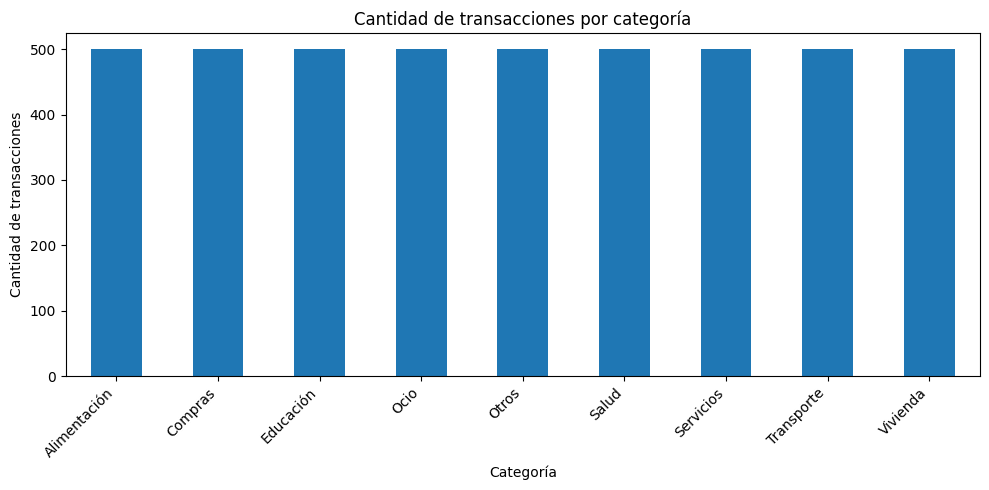

,cantidad
categoria,
Alimentación,500
Compras,500
Educación,500
Ocio,500
Otros,500
Salud,500
Servicios,500
Transporte,500
Vivienda,500


In [42]:
conteo_categorias = (
    transacciones["categoria"]
    .value_counts()
    .sort_index()
)

ax = conteo_categorias.plot(
    kind="bar",
    figsize=(10, 5),
    title="Cantidad de transacciones por categoría",
)
ax.set_xlabel("Categoría")
ax.set_ylabel("Cantidad de transacciones")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

display(conteo_categorias.rename("cantidad").to_frame())

**Interpretación:** las nueve categorías poseen la misma cantidad de registros. Esto elimina el desbalance de clases durante el entrenamiento, aunque representa una distribución más controlada que la que suele observarse en datos financieros reales.

## 7. Distribución de perfiles financieros

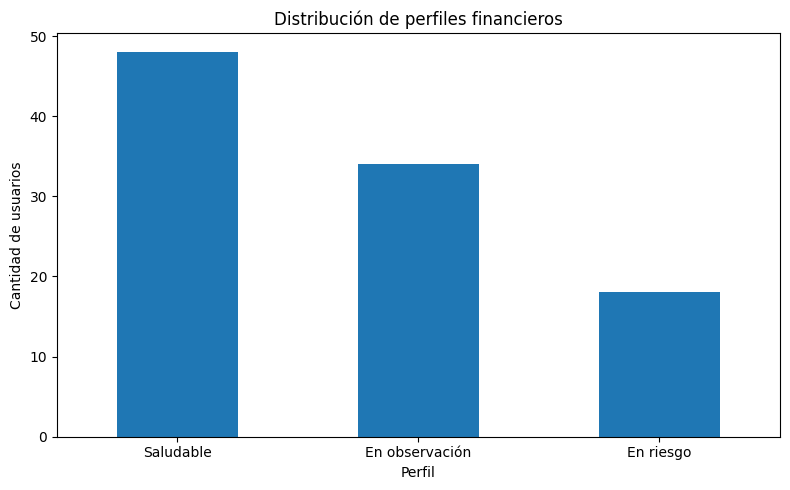

,cantidad
perfil_financiero,
Saludable,48
En observación,34
En riesgo,18


In [43]:
conteo_perfiles = usuarios["perfil_financiero"].value_counts()

ax = conteo_perfiles.plot(
    kind="bar",
    figsize=(8, 5),
    title="Distribución de perfiles financieros",
)
ax.set_xlabel("Perfil")
ax.set_ylabel("Cantidad de usuarios")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

display(conteo_perfiles.rename("cantidad").to_frame())

**Interpretación:** la variable objetivo de perfil está moderadamente desbalanceada. Por eso se utilizará una partición estratificada y `class_weight="balanced"`.

## 8. Gastos por categoría y medios de pago

,count,sum,mean,median,max
categoria,,,,,
Vivienda,500,"511,885.3400","1,023.7707",974.3300,"2,000.0000"
Compras,500,"262,304.8000",524.6096,492.6500,"1,000.0000"
Educación,500,"252,289.2700",504.5785,478.7950,"1,000.0000"
Salud,500,"130,265.8000",260.5316,241.6750,500.0000
Otros,500,"128,989.9100",257.9798,246.7000,500.0000
Servicios,500,"107,920.9300",215.8419,207.4450,400.0000
Ocio,500,"79,227.8500",158.4557,146.0200,300.0000
Alimentación,500,"54,742.0100",109.4840,106.5700,200.0000
Transporte,500,"46,667.8600",93.3357,89.4250,180.0000


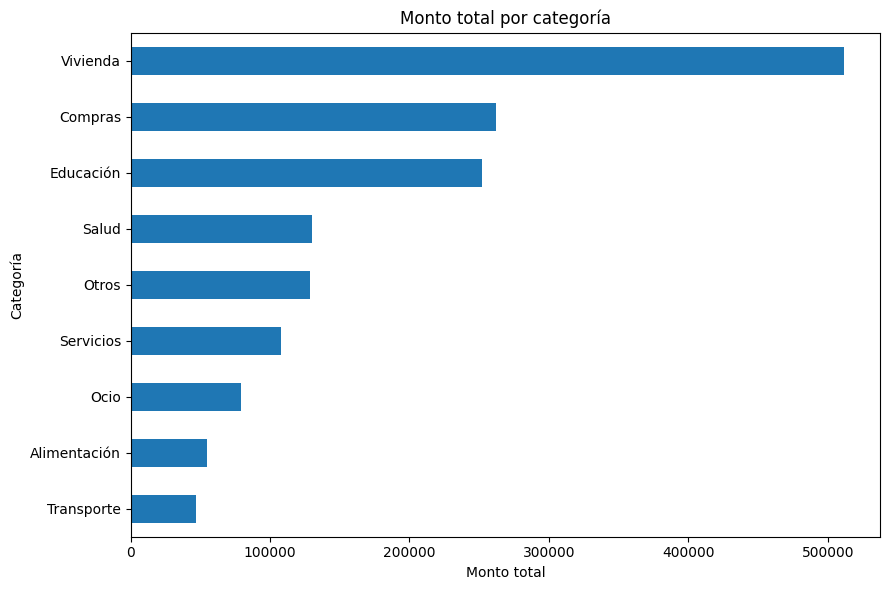

In [44]:
resumen_categoria = (
    transacciones.groupby("categoria")["monto"]
    .agg(["count", "sum", "mean", "median", "max"])
    .sort_values("sum", ascending=False)
)

display(resumen_categoria)

ax = resumen_categoria["sum"].sort_values().plot(
    kind="barh",
    figsize=(9, 6),
    title="Monto total por categoría",
)
ax.set_xlabel("Monto total")
ax.set_ylabel("Categoría")
plt.tight_layout()
plt.show()

In [45]:
display(
    transacciones["medio_pago"]
    .value_counts()
    .rename("cantidad")
    .to_frame()
)

,cantidad
medio_pago,
Débito automático,658
Billetera virtual,648
Tarjeta de crédito,648
Pago con QR,644
Transferencia bancaria,644
Efectivo,640
Tarjeta de débito,618


## 9. Relación entre variables financieras

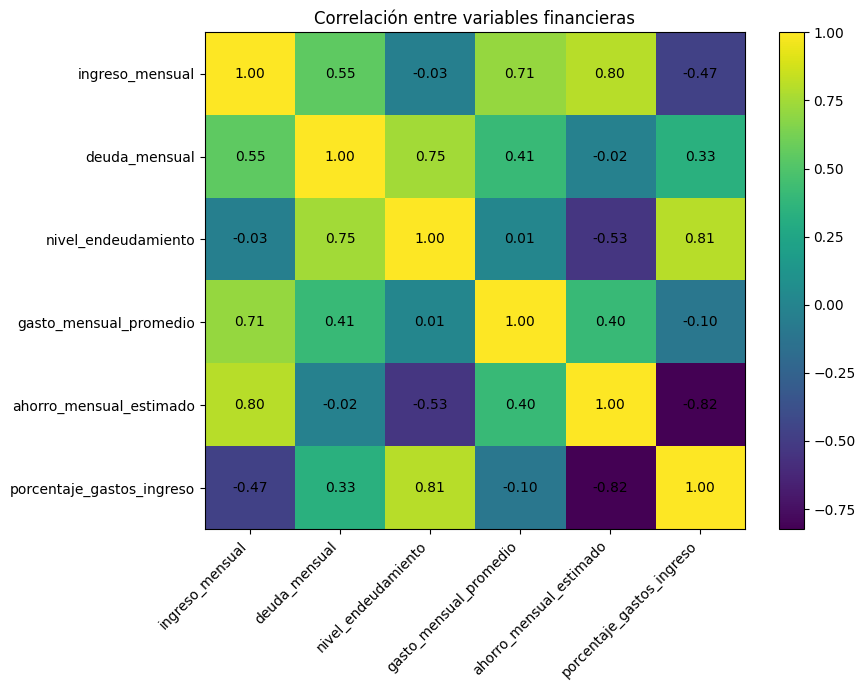

In [46]:
variables_correlacion = [
    "ingreso_mensual",
    "deuda_mensual",
    "nivel_endeudamiento",
    "gasto_mensual_promedio",
    "ahorro_mensual_estimado",
    "porcentaje_gastos_ingreso",
]

correlaciones = usuarios[variables_correlacion].corr()

fig, ax = plt.subplots(figsize=(9, 7))
imagen = ax.imshow(correlaciones, aspect="auto")
ax.set_xticks(range(len(correlaciones.columns)))
ax.set_yticks(range(len(correlaciones.index)))
ax.set_xticklabels(correlaciones.columns, rotation=45, ha="right")
ax.set_yticklabels(correlaciones.index)

for fila in range(len(correlaciones.index)):
    for columna in range(len(correlaciones.columns)):
        ax.text(
            columna,
            fila,
            f"{correlaciones.iloc[fila, columna]:.2f}",
            ha="center",
            va="center",
        )

ax.set_title("Correlación entre variables financieras")
fig.colorbar(imagen, ax=ax)
plt.tight_layout()
plt.show()

# 10. Procesamiento financiero, textual e ingeniería de atributos

Se crean variables temporales, monetarias y textuales que luego serán utilizadas por los modelos.

In [47]:
def crear_features_transacciones(df: pd.DataFrame) -> pd.DataFrame:
    resultado = df.copy()

    resultado["anio"] = resultado["fecha"].dt.year
    resultado["mes"] = resultado["fecha"].dt.month
    resultado["trimestre"] = resultado["fecha"].dt.quarter
    resultado["dia_semana"] = resultado["fecha"].dt.dayofweek
    resultado["es_fin_de_semana"] = (
        resultado["dia_semana"].isin([5, 6]).astype(int)
    )

    resultado["monto_log"] = np.log1p(resultado["monto"])
    resultado["longitud_descripcion"] = (
        resultado["descripcion_limpia"].str.len()
    )
    resultado["cantidad_palabras"] = (
        resultado["descripcion_limpia"].str.split().str.len()
    )
    resultado["recurrente_binario"] = (
        resultado["recurrente"]
        .str.lower()
        .map({"sí": 1, "si": 1, "no": 0})
        .fillna(0)
        .astype(int)
    )

    mediana_por_usuario = (
        resultado.groupby("usuario_id")["monto"]
        .transform("median")
    )
    resultado["es_gasto_grande"] = (
        resultado["monto"] > (2 * mediana_por_usuario)
    ).astype(int)

    return resultado


transacciones_features = crear_features_transacciones(transacciones)

columnas_features_creadas = [
    "descripcion_limpia",
    "anio",
    "mes",
    "trimestre",
    "dia_semana",
    "es_fin_de_semana",
    "monto_log",
    "longitud_descripcion",
    "cantidad_palabras",
    "recurrente_binario",
    "es_gasto_grande",
]

display(transacciones_features[columnas_features_creadas].head())

,descripcion_limpia,anio,mes,trimestre,dia_semana,es_fin_de_semana,monto_log,longitud_descripcion,cantidad_palabras,recurrente_binario,es_gasto_grande
0,servicio de limpieza,2026,6,2,6,1,7.4917,20,3,0,1
1,cena,2025,10,4,6,1,5.3033,4,1,0,0
2,parque recreativo,2026,4,2,0,0,2.2246,17,2,0,0
3,compra de muebles,2025,8,3,6,1,5.1759,17,3,1,0
4,suscripcion de musica,2026,5,2,4,0,4.4283,21,3,0,0


## 11. Variables agregadas por usuario

In [48]:
resumen_transacciones_usuario = (
    transacciones_features
    .groupby("usuario_id")
    .agg(
        cantidad_transacciones=("transaction_id", "count"),
        gasto_total=("monto", "sum"),
        gasto_promedio_transaccion=("monto", "mean"),
        gasto_mediano=("monto", "median"),
        gasto_maximo=("monto", "max"),
        desviacion_gastos=("monto", "std"),
        cantidad_recurrentes=("recurrente_binario", "sum"),
        cantidad_gastos_grandes=("es_gasto_grande", "sum"),
        categorias_distintas=("categoria", "nunique"),
    )
    .reset_index()
)

dataset_perfiles = usuarios.merge(
    resumen_transacciones_usuario,
    on="usuario_id",
    how="left",
    validate="one_to_one",
)

dataset_perfiles["ratio_deuda_ingreso_calculado"] = np.where(
    dataset_perfiles["ingreso_mensual"] > 0,
    dataset_perfiles["deuda_mensual"] / dataset_perfiles["ingreso_mensual"],
    0,
)

dataset_perfiles["ratio_gasto_ingreso_calculado"] = np.where(
    dataset_perfiles["ingreso_mensual"] > 0,
    dataset_perfiles["gasto_mensual_promedio"]
    / dataset_perfiles["ingreso_mensual"],
    0,
)

dataset_perfiles["ratio_ahorro_ingreso_calculado"] = np.where(
    dataset_perfiles["ingreso_mensual"] > 0,
    dataset_perfiles["ahorro_mensual_estimado"]
    / dataset_perfiles["ingreso_mensual"],
    0,
)

display(dataset_perfiles.head())

,usuario_id,ingreso_mensual,deuda_mensual,nivel_endeudamiento,gasto_mensual_promedio,ahorro_mensual_estimado,porcentaje_gastos_ingreso,frecuencia_ahorro,perfil_financiero,cantidad_transacciones,gasto_total,gasto_promedio_transaccion,gasto_mediano,gasto_maximo,desviacion_gastos,cantidad_recurrentes,cantidad_gastos_grandes,categorias_distintas,ratio_deuda_ingreso_calculado,ratio_gasto_ingreso_calculado,ratio_ahorro_ingreso_calculado
0,USR0001,"4,379.0900",832.9000,19.0200,"1,114.3100","2,431.8800",44.4700,Alta,Saludable,40,"13,371.7600",334.2940,227.5900,"2,000.0000",379.3590,10,9,9,0.1902,0.2545,0.5553
1,USR0002,"6,100.1400",968.0900,15.8700,"1,013.9600","4,118.0900",32.4900,Alta,Saludable,34,"12,167.5000",357.8676,181.6650,"1,627.5500",384.7332,13,13,8,0.1587,0.1662,0.6751
2,USR0003,"4,160.0000",786.6600,18.9100,"1,708.7300","1,664.6100",59.9900,Alta,Saludable,49,"20,504.7000",418.4633,200.0000,"2,000.0000",471.1477,14,16,9,0.1891,0.4108,0.4001
3,USR0004,"3,609.8600","1,933.4400",53.5600,"1,306.0100",370.4100,89.7400,Media,En riesgo,37,"15,672.1200",423.5708,273.0600,"1,818.1500",411.7149,11,9,9,0.5356,0.3618,0.1026
4,USR0005,"1,801.6500",440.6800,24.4600,714.5500,646.4200,64.1200,Alta,Saludable,35,"8,574.5600",244.9874,150.7400,"1,267.2800",264.4697,10,11,8,0.2446,0.3966,0.3588


## 12. Exportación de datasets procesados

In [49]:
RUTA_TRANSACCIONES_PROCESADAS = (
    PROCESSED_DIR / "transacciones_features.csv"
)
RUTA_PERFILES_PROCESADOS = (
    PROCESSED_DIR / "usuarios_features.csv"
)

transacciones_features.to_csv(
    RUTA_TRANSACCIONES_PROCESADAS,
    index=False,
)
dataset_perfiles.to_csv(
    RUTA_PERFILES_PROCESADOS,
    index=False,
)

print(RUTA_TRANSACCIONES_PROCESADAS)
print(RUTA_PERFILES_PROCESADOS)

artefactos_financeai_v3/datos_procesados/transacciones_features.csv
artefactos_financeai_v3/datos_procesados/usuarios_features.csv


# 13. Modelo de clasificación de gastos

El modelo combina:

- TF-IDF para la descripción textual.
- Variables numéricas de la transacción.
- Codificación One-Hot para medio de pago y recurrencia.
- Regresión logística multiclase.

Se realizan dos evaluaciones:

1. **Hold-out estratificado por transacción**, útil para transacciones de conceptos ya conocidos.
2. **Validación agrupada por descripción**, más exigente, porque evita que una misma descripción aparezca tanto en entrenamiento como en validación.

In [50]:
features_categoria = [
    "descripcion_limpia",
    "monto",
    "mes",
    "dia_semana",
    "es_fin_de_semana",
    "longitud_descripcion",
    "cantidad_palabras",
    "medio_pago",
    "recurrente",
]

target_categoria = "categoria"

X_categoria = transacciones_features[features_categoria].copy()
y_categoria = transacciones_features[target_categoria].copy()

preprocesador_categoria = ColumnTransformer(
    transformers=[
        (
            "texto",
            TfidfVectorizer(
                ngram_range=(1, 2),
                min_df=2,
                max_features=5000,
                sublinear_tf=True,
            ),
            "descripcion_limpia",
        ),
        (
            "numericas",
            Pipeline([
                ("imputacion", SimpleImputer(strategy="median")),
                ("escalado", StandardScaler()),
            ]),
            [
                "monto",
                "mes",
                "dia_semana",
                "es_fin_de_semana",
                "longitud_descripcion",
                "cantidad_palabras",
            ],
        ),
        (
            "categoricas",
            OneHotEncoder(handle_unknown="ignore"),
            ["medio_pago", "recurrente"],
        ),
    ]
)

modelo_categoria = Pipeline([
    ("preprocesamiento", preprocesador_categoria),
    (
        "clasificador",
        LogisticRegression(
            max_iter=2500,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
    ),
])

## 14. Evaluación clásica por transacción

In [51]:
X_cat_train, X_cat_test, y_cat_train, y_cat_test = train_test_split(
    X_categoria,
    y_categoria,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_categoria,
)

modelo_categoria.fit(X_cat_train, y_cat_train)
pred_categoria = modelo_categoria.predict(X_cat_test)

metricas_categoria_holdout = {
    "accuracy": accuracy_score(y_cat_test, pred_categoria),
    "f1_macro": f1_score(y_cat_test, pred_categoria, average="macro"),
    "f1_weighted": f1_score(
        y_cat_test,
        pred_categoria,
        average="weighted",
    ),
}

display(
    pd.Series(
        metricas_categoria_holdout,
        name="clasificacion_gastos_holdout",
    ).round(4)
)

print(classification_report(
    y_cat_test,
    pred_categoria,
    zero_division=0,
))

,clasificacion_gastos_holdout
accuracy,1.0000
f1_macro,1.0000
f1_weighted,1.0000


              precision    recall  f1-score   support

Alimentación       1.00      1.00      1.00       100
     Compras       1.00      1.00      1.00       100
   Educación       1.00      1.00      1.00       100
        Ocio       1.00      1.00      1.00       100
       Otros       1.00      1.00      1.00       100
       Salud       1.00      1.00      1.00       100
   Servicios       1.00      1.00      1.00       100
  Transporte       1.00      1.00      1.00       100
    Vivienda       1.00      1.00      1.00       100

    accuracy                           1.00       900
   macro avg       1.00      1.00      1.00       900
weighted avg       1.00      1.00      1.00       900



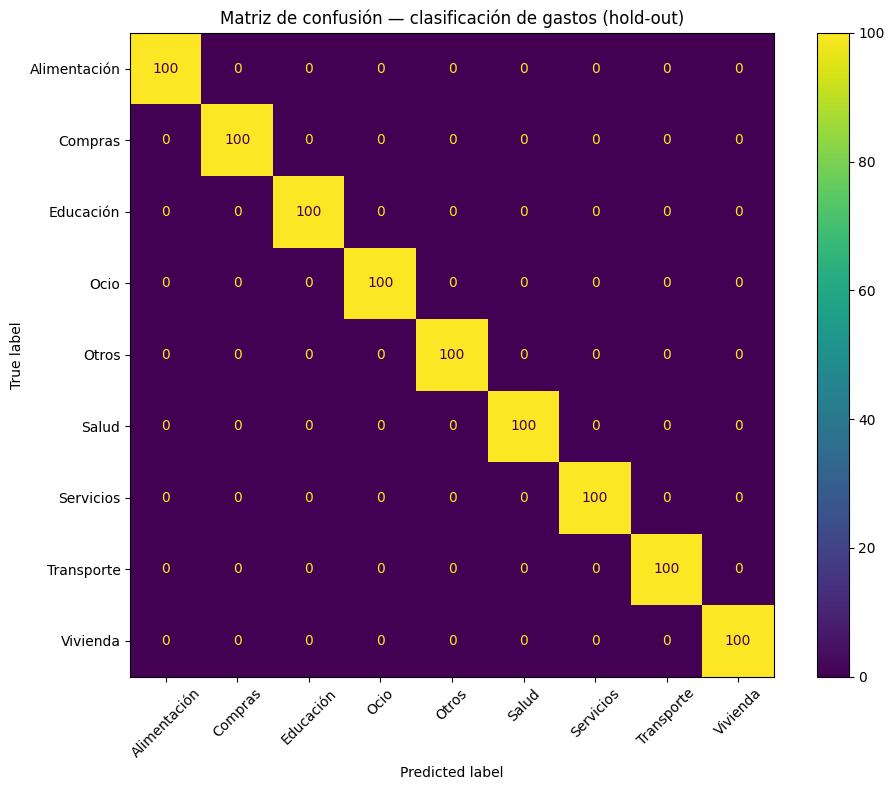

In [52]:
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_cat_test,
    pred_categoria,
    xticks_rotation=45,
    ax=ax,
)
ax.set_title(
    "Matriz de confusión — clasificación de gastos (hold-out)"
)
plt.tight_layout()
plt.show()

### Interpretación del resultado perfecto

La evaluación aleatoria puede producir métricas perfectas porque el dataset contiene un vocabulario sintético controlado: cada descripción se asocia de forma prácticamente unívoca con una categoría y una misma descripción puede aparecer en entrenamiento y prueba.

Por eso esta evaluación valida correctamente el funcionamiento del pipeline ante nuevas transacciones de conceptos conocidos, pero no alcanza por sí sola para demostrar generalización frente a descripciones nunca observadas.

## 15. Evaluación robusta agrupada por descripción

In [53]:
grupos_descripcion = transacciones_features["descripcion_limpia"]

cv_agrupada = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

resultados_cv_categoria = cross_validate(
    modelo_categoria,
    X_categoria,
    y_categoria,
    groups=grupos_descripcion,
    cv=cv_agrupada,
    scoring={
        "accuracy": "accuracy",
        "f1_macro": "f1_macro",
        "f1_weighted": "f1_weighted",
    },
    return_train_score=False,
    n_jobs=None,
)

resumen_cv_categoria = pd.DataFrame({
    "metrica": ["accuracy", "f1_macro", "f1_weighted"],
    "promedio": [
        resultados_cv_categoria["test_accuracy"].mean(),
        resultados_cv_categoria["test_f1_macro"].mean(),
        resultados_cv_categoria["test_f1_weighted"].mean(),
    ],
    "desvio_estandar": [
        resultados_cv_categoria["test_accuracy"].std(),
        resultados_cv_categoria["test_f1_macro"].std(),
        resultados_cv_categoria["test_f1_weighted"].std(),
    ],
})

display(resumen_cv_categoria.round(4))

,metrica,promedio,desvio_estandar
0,accuracy,0.3973,0.0423
1,f1_macro,0.3163,0.0548
2,f1_weighted,0.3970,0.0556


In [54]:
indices_train_group, indices_test_group = next(
    cv_agrupada.split(
        X_categoria,
        y_categoria,
        groups=grupos_descripcion,
    )
)

X_cat_group_train = X_categoria.iloc[indices_train_group].copy()
X_cat_group_test = X_categoria.iloc[indices_test_group].copy()
y_cat_group_train = y_categoria.iloc[indices_train_group].copy()
y_cat_group_test = y_categoria.iloc[indices_test_group].copy()

modelo_categoria_agrupado = Pipeline([
    ("preprocesamiento", preprocesador_categoria),
    (
        "clasificador",
        LogisticRegression(
            max_iter=2500,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
    ),
])

modelo_categoria_agrupado.fit(
    X_cat_group_train,
    y_cat_group_train,
)

pred_categoria_agrupada = modelo_categoria_agrupado.predict(
    X_cat_group_test
)

descripciones_compartidas = set(
    X_cat_group_train["descripcion_limpia"]
) & set(
    X_cat_group_test["descripcion_limpia"]
)

print(
    "Descripciones compartidas entre entrenamiento y prueba:",
    len(descripciones_compartidas),
)

print(classification_report(
    y_cat_group_test,
    pred_categoria_agrupada,
    zero_division=0,
))

Descripciones compartidas entre entrenamiento y prueba: 0
              precision    recall  f1-score   support

Alimentación       0.83      0.53      0.65       104
     Compras       0.38      1.00      0.55        45
   Educación       0.50      0.41      0.45       142
        Ocio       0.00      0.00      0.00        89
       Otros       0.37      1.00      0.54        52
       Salud       0.14      0.14      0.14       163
   Servicios       0.38      0.36      0.37       131
  Transporte       0.54      0.50      0.52        90
    Vivienda       0.62      0.50      0.55        56

    accuracy                           0.40       872
   macro avg       0.42      0.49      0.42       872
weighted avg       0.40      0.40      0.38       872



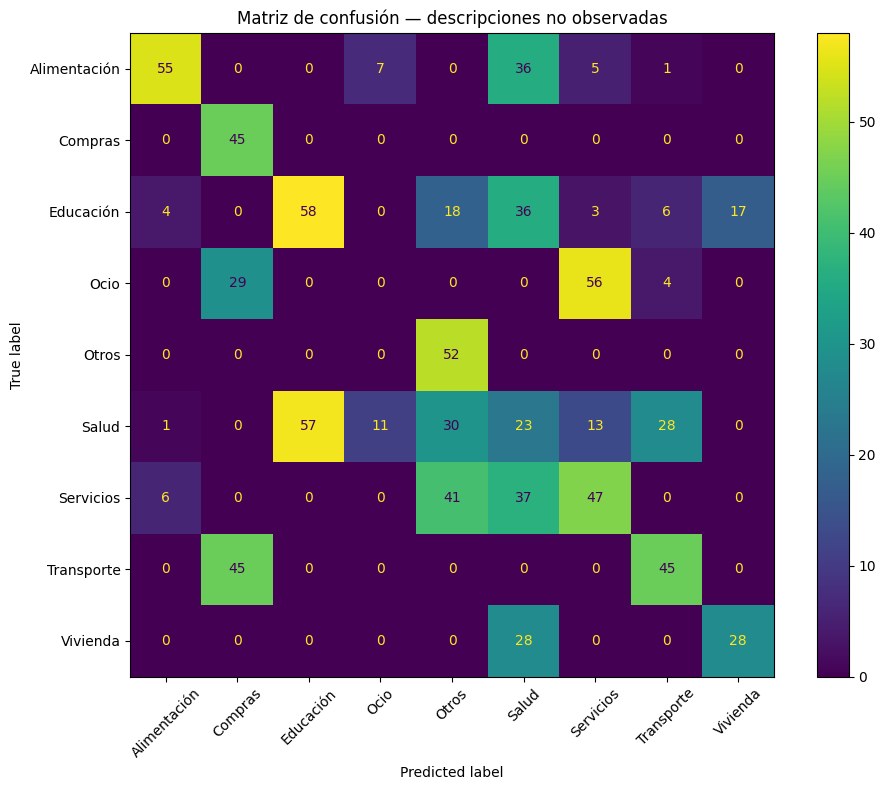

In [55]:
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_cat_group_test,
    pred_categoria_agrupada,
    xticks_rotation=45,
    ax=ax,
)
ax.set_title(
    "Matriz de confusión — descripciones no observadas"
)
plt.tight_layout()
plt.show()

La evaluación agrupada representa un escenario más exigente: cada descripción queda exclusivamente en entrenamiento o validación. Esta métrica es más útil para estimar la capacidad de generalización a comercios o conceptos textuales no vistos.

## 16. Interpretabilidad del clasificador de gastos

Se muestran los términos con mayor peso positivo para cada categoría. Esta inspección permite verificar qué vocabulario utiliza el modelo para tomar decisiones.

In [56]:
modelo_categoria.fit(X_categoria, y_categoria)

preprocesador_entrenado = modelo_categoria.named_steps[
    "preprocesamiento"
]
clasificador_entrenado = modelo_categoria.named_steps[
    "clasificador"
]

nombres_features = preprocesador_entrenado.get_feature_names_out()
coeficientes = clasificador_entrenado.coef_
clases_categoria = clasificador_entrenado.classes_

filas_terminos = []

for indice_clase, clase in enumerate(clases_categoria):
    mejores_indices = np.argsort(
        coeficientes[indice_clase]
    )[-8:][::-1]

    for posicion, indice_feature in enumerate(
        mejores_indices,
        start=1,
    ):
        filas_terminos.append({
            "categoria": clase,
            "posicion": posicion,
            "feature": nombres_features[indice_feature],
            "coeficiente": coeficientes[
                indice_clase,
                indice_feature,
            ],
        })

terminos_importantes = pd.DataFrame(filas_terminos)
display(terminos_importantes)

,categoria,posicion,feature,coeficiente
0,Alimentación,1,texto__verduleria,3.3102
1,Alimentación,2,texto__restaurante,3.1907
2,Alimentación,3,texto__almuerzo,3.1625
3,Alimentación,4,texto__panaderia,3.1322
4,Alimentación,5,texto__carniceria,3.1047
...,...,...,...,...
67,Vivienda,4,texto__de muebles,2.9318
68,Vivienda,5,texto__muebles,2.9318
69,Vivienda,6,texto__hogar,2.4945
70,Vivienda,7,texto__del hogar,2.4945


# 17. Modelo de perfil financiero

El objetivo es predecir uno de los perfiles:

- Saludable
- En observación
- En riesgo

El modelo utiliza variables financieras declaradas y atributos agregados a partir del comportamiento transaccional.

In [57]:
features_perfil_numericas = [
    "ingreso_mensual",
    "deuda_mensual",
    "nivel_endeudamiento",
    "gasto_mensual_promedio",
    "ahorro_mensual_estimado",
    "porcentaje_gastos_ingreso",
    "cantidad_transacciones",
    "gasto_total",
    "gasto_promedio_transaccion",
    "gasto_mediano",
    "gasto_maximo",
    "desviacion_gastos",
    "cantidad_recurrentes",
    "cantidad_gastos_grandes",
    "categorias_distintas",
    "ratio_deuda_ingreso_calculado",
    "ratio_gasto_ingreso_calculado",
    "ratio_ahorro_ingreso_calculado",
]

features_perfil_categoricas = [
    "frecuencia_ahorro",
]

features_perfil = (
    features_perfil_numericas
    + features_perfil_categoricas
)

target_perfil = "perfil_financiero"

X_perfil = dataset_perfiles[features_perfil].copy()
y_perfil = dataset_perfiles[target_perfil].copy()

preprocesador_perfil = ColumnTransformer(
    transformers=[
        (
            "numericas",
            Pipeline([
                ("imputacion", SimpleImputer(strategy="median")),
                ("escalado", StandardScaler()),
            ]),
            features_perfil_numericas,
        ),
        (
            "categoricas",
            OneHotEncoder(handle_unknown="ignore"),
            features_perfil_categoricas,
        ),
    ]
)

modelo_perfil = Pipeline([
    ("preprocesamiento", preprocesador_perfil),
    (
        "clasificador",
        LogisticRegression(
            max_iter=2500,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
    ),
])

## 18. Evaluación hold-out

In [58]:
X_perfil_train, X_perfil_test, y_perfil_train, y_perfil_test = (
    train_test_split(
        X_perfil,
        y_perfil,
        test_size=0.25,
        random_state=RANDOM_STATE,
        stratify=y_perfil,
    )
)

modelo_perfil.fit(X_perfil_train, y_perfil_train)
pred_perfil = modelo_perfil.predict(X_perfil_test)

metricas_perfil_holdout = {
    "accuracy": accuracy_score(y_perfil_test, pred_perfil),
    "f1_macro": f1_score(
        y_perfil_test,
        pred_perfil,
        average="macro",
    ),
    "f1_weighted": f1_score(
        y_perfil_test,
        pred_perfil,
        average="weighted",
    ),
}

display(
    pd.Series(
        metricas_perfil_holdout,
        name="clasificacion_perfil_holdout",
    ).round(4)
)

print(classification_report(
    y_perfil_test,
    pred_perfil,
    zero_division=0,
))

,clasificacion_perfil_holdout
accuracy,0.8400
f1_macro,0.8396
f1_weighted,0.8402


                precision    recall  f1-score   support

En observación       0.75      0.75      0.75         8
     En riesgo       1.00      0.80      0.89         5
     Saludable       0.85      0.92      0.88        12

      accuracy                           0.84        25
     macro avg       0.87      0.82      0.84        25
  weighted avg       0.85      0.84      0.84        25



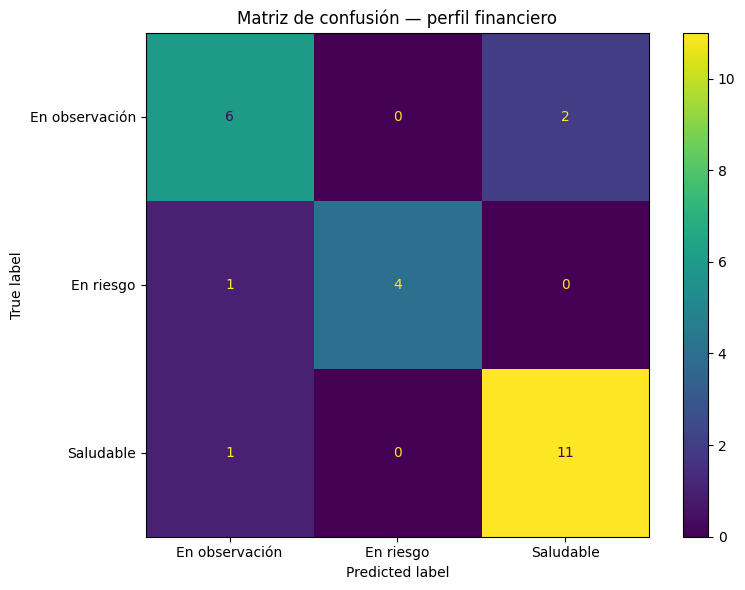

In [59]:
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_perfil_test,
    pred_perfil,
    ax=ax,
)
ax.set_title("Matriz de confusión — perfil financiero")
plt.tight_layout()
plt.show()

### Limitación de la evaluación hold-out

El conjunto de prueba contiene 25 usuarios. Es suficiente para una validación técnica inicial, pero una muestra pequeña puede producir métricas variables. Por eso se agrega validación cruzada estratificada, que utiliza distintas particiones del conjunto de usuarios.

## 19. Validación cruzada estratificada

In [60]:
cv_perfil = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

resultados_cv_perfil = cross_validate(
    modelo_perfil,
    X_perfil,
    y_perfil,
    cv=cv_perfil,
    scoring={
        "accuracy": "accuracy",
        "f1_macro": "f1_macro",
        "f1_weighted": "f1_weighted",
    },
    return_train_score=False,
    n_jobs=None,
)

resumen_cv_perfil = pd.DataFrame({
    "metrica": ["accuracy", "f1_macro", "f1_weighted"],
    "promedio": [
        resultados_cv_perfil["test_accuracy"].mean(),
        resultados_cv_perfil["test_f1_macro"].mean(),
        resultados_cv_perfil["test_f1_weighted"].mean(),
    ],
    "desvio_estandar": [
        resultados_cv_perfil["test_accuracy"].std(),
        resultados_cv_perfil["test_f1_macro"].std(),
        resultados_cv_perfil["test_f1_weighted"].std(),
    ],
})

display(resumen_cv_perfil.round(4))

,metrica,promedio,desvio_estandar
0,accuracy,0.9300,0.0510
1,f1_macro,0.9245,0.0539
2,f1_weighted,0.9279,0.0544


## 20. Interpretabilidad del modelo de perfil

In [61]:
modelo_perfil.fit(X_perfil, y_perfil)

preprocesador_perfil_entrenado = modelo_perfil.named_steps[
    "preprocesamiento"
]
clasificador_perfil_entrenado = modelo_perfil.named_steps[
    "clasificador"
]

nombres_features_perfil = (
    preprocesador_perfil_entrenado.get_feature_names_out()
)
coeficientes_perfil = clasificador_perfil_entrenado.coef_
clases_perfil = clasificador_perfil_entrenado.classes_

filas_importancia_perfil = []

for indice_clase, clase in enumerate(clases_perfil):
    mejores_indices = np.argsort(
        coeficientes_perfil[indice_clase]
    )[-8:][::-1]

    for posicion, indice_feature in enumerate(
        mejores_indices,
        start=1,
    ):
        filas_importancia_perfil.append({
            "perfil": clase,
            "posicion": posicion,
            "feature": nombres_features_perfil[indice_feature],
            "coeficiente": coeficientes_perfil[
                indice_clase,
                indice_feature,
            ],
        })

importancia_perfil = pd.DataFrame(
    filas_importancia_perfil
)
display(importancia_perfil)

,perfil,posicion,feature,coeficiente
0,En observación,1,categoricas__frecuencia_ahorro_Media,0.7022
1,En observación,2,numericas__ahorro_mensual_estimado,0.3454
2,En observación,3,numericas__gasto_maximo,0.1858
3,En observación,4,numericas__ingreso_mensual,0.1771
4,En observación,5,numericas__categorias_distintas,0.1256
5,En observación,6,numericas__ratio_gasto_ingreso_calculado,0.1017
6,En observación,7,numericas__gasto_total,0.0868
7,En observación,8,numericas__gasto_mensual_promedio,0.0868
8,En riesgo,1,numericas__deuda_mensual,1.4535
9,En riesgo,2,numericas__ratio_deuda_ingreso_calculado,1.3134


# 21. Inferencia, recomendaciones y contrato JSON

Esta sección simula el comportamiento esperado en producción. El backend enviará datos de una transacción o un usuario, y el servicio de Ciencia de Datos devolverá predicciones, probabilidades, métricas y recomendaciones.

In [62]:
def preparar_transaccion_inferencia(
    descripcion: str,
    monto: float,
    fecha: str,
    medio_pago: str,
    recurrente: str,
) -> pd.DataFrame:
    fecha_convertida = pd.Timestamp(fecha)
    descripcion_limpia = normalizar_texto(descripcion)

    return pd.DataFrame([{
        "descripcion_limpia": descripcion_limpia,
        "monto": float(monto),
        "mes": fecha_convertida.month,
        "dia_semana": fecha_convertida.dayofweek,
        "es_fin_de_semana": int(
            fecha_convertida.dayofweek in [5, 6]
        ),
        "longitud_descripcion": len(descripcion_limpia),
        "cantidad_palabras": len(
            descripcion_limpia.split()
        ),
        "medio_pago": medio_pago,
        "recurrente": recurrente,
    }])


def predecir_categoria(
    descripcion: str,
    monto: float,
    fecha: str,
    medio_pago: str,
    recurrente: str,
) -> dict:
    entrada = preparar_transaccion_inferencia(
        descripcion=descripcion,
        monto=monto,
        fecha=fecha,
        medio_pago=medio_pago,
        recurrente=recurrente,
    )

    categoria = modelo_categoria.predict(entrada)[0]
    probabilidades = modelo_categoria.predict_proba(
        entrada
    )[0]
    clases = modelo_categoria.classes_
    indice_categoria = list(clases).index(categoria)

    return {
        "categoria_predicha": str(categoria),
        "confianza": round(
            float(probabilidades[indice_categoria]),
            4,
        ),
    }

## 22. Tres casos de uso para clasificación de gastos

In [63]:
casos_transacciones = [
    {
        "descripcion": "Compra semanal en supermercado",
        "monto": 85.40,
        "fecha": "2026-07-16",
        "medio_pago": "Billetera virtual",
        "recurrente": "No",
    },
    {
        "descripcion": "Pago de plataforma de streaming",
        "monto": 14.99,
        "fecha": "2026-07-12",
        "medio_pago": "Débito automático",
        "recurrente": "Sí",
    },
    {
        "descripcion": "Consulta médica y medicamentos",
        "monto": 72.50,
        "fecha": "2026-07-15",
        "medio_pago": "Tarjeta de crédito",
        "recurrente": "No",
    },
]

resultados_casos = []

for caso in casos_transacciones:
    resultado = predecir_categoria(**caso)
    resultados_casos.append({
        **caso,
        **resultado,
    })

display(pd.DataFrame(resultados_casos))

,descripcion,monto,fecha,medio_pago,recurrente,categoria_predicha,confianza
0,Compra semanal en supermercado,85.4000,2026-07-16,Billetera virtual,No,Alimentación,0.5450
1,Pago de plataforma de streaming,14.9900,2026-07-12,Débito automático,Sí,Ocio,0.4475
2,Consulta médica y medicamentos,72.5000,2026-07-15,Tarjeta de crédito,No,Salud,0.6392


In [64]:
def generar_recomendaciones(
    fila_usuario: pd.Series,
) -> list[str]:
    recomendaciones = []

    ratio_gasto = float(
        fila_usuario["ratio_gasto_ingreso_calculado"]
    )
    ratio_deuda = float(
        fila_usuario["ratio_deuda_ingreso_calculado"]
    )
    ratio_ahorro = float(
        fila_usuario["ratio_ahorro_ingreso_calculado"]
    )
    recurrentes = int(
        fila_usuario["cantidad_recurrentes"]
    )

    if ratio_gasto >= 0.80:
        recomendaciones.append(
            "Reducir los gastos mensuales y priorizar las categorías esenciales."
        )
    elif ratio_gasto >= 0.60:
        recomendaciones.append(
            "Revisar las categorías de mayor consumo para liberar capacidad de ahorro."
        )
    else:
        recomendaciones.append(
            "Mantener el nivel de gasto actual y revisar el presupuesto periódicamente."
        )

    if ratio_deuda >= 0.35:
        recomendaciones.append(
            "Priorizar la reducción de deuda antes de asumir nuevos compromisos financieros."
        )
    elif ratio_deuda >= 0.20:
        recomendaciones.append(
            "Evitar incrementar la deuda y planificar pagos anticipados cuando sea posible."
        )
    else:
        recomendaciones.append(
            "El nivel de endeudamiento se encuentra controlado."
        )

    if ratio_ahorro < 0.10:
        recomendaciones.append(
            "Definir un objetivo inicial de ahorro de al menos el 10% del ingreso mensual."
        )
    elif ratio_ahorro < 0.20:
        recomendaciones.append(
            "Incrementar gradualmente el porcentaje destinado al ahorro."
        )
    else:
        recomendaciones.append(
            "Mantener el hábito de ahorro y considerar un fondo de emergencia."
        )

    if recurrentes >= 15:
        recomendaciones.append(
            "Auditar suscripciones y débitos automáticos para eliminar cargos innecesarios."
        )

    return recomendaciones


def analizar_usuario(usuario_id: str) -> dict:
    coincidencias = dataset_perfiles[
        dataset_perfiles["usuario_id"] == usuario_id
    ]

    if coincidencias.empty:
        raise ValueError(
            f"No existe el usuario {usuario_id}."
        )

    fila = coincidencias.iloc[0]
    entrada_perfil = fila[features_perfil].to_frame().T

    perfil_predicho = modelo_perfil.predict(
        entrada_perfil
    )[0]

    probabilidades = modelo_perfil.predict_proba(
        entrada_perfil
    )[0]
    clases = modelo_perfil.classes_
    indice_perfil = list(clases).index(
        perfil_predicho
    )

    transacciones_usuario = transacciones_features[
        transacciones_features["usuario_id"]
        == usuario_id
    ]

    categorias_principales = (
        transacciones_usuario.groupby("categoria")["monto"]
        .sum()
        .sort_values(ascending=False)
        .head(3)
    )

    total_gastado = float(
        transacciones_usuario["monto"].sum()
    )

    categorias_json = []

    for categoria, monto in categorias_principales.items():
        porcentaje = (
            float(monto) / total_gastado * 100
            if total_gastado > 0
            else 0
        )
        categorias_json.append({
            "categoria": str(categoria),
            "monto": round(float(monto), 2),
            "porcentaje": round(porcentaje, 2),
        })

    return {
        "usuario_id": str(usuario_id),
        "perfil_financiero": str(perfil_predicho),
        "confianza_perfil": round(
            float(probabilidades[indice_perfil]),
            4,
        ),
        "metricas": {
            "ingreso_mensual": round(
                float(fila["ingreso_mensual"]),
                2,
            ),
            "gasto_mensual_promedio": round(
                float(fila["gasto_mensual_promedio"]),
                2,
            ),
            "deuda_mensual": round(
                float(fila["deuda_mensual"]),
                2,
            ),
            "ahorro_mensual_estimado": round(
                float(fila["ahorro_mensual_estimado"]),
                2,
            ),
            "ratio_gasto_ingreso": round(
                float(
                    fila[
                        "ratio_gasto_ingreso_calculado"
                    ]
                ),
                4,
            ),
            "ratio_deuda_ingreso": round(
                float(
                    fila[
                        "ratio_deuda_ingreso_calculado"
                    ]
                ),
                4,
            ),
            "ratio_ahorro_ingreso": round(
                float(
                    fila[
                        "ratio_ahorro_ingreso_calculado"
                    ]
                ),
                4,
            ),
        },
        "categorias_principales": categorias_json,
        "recomendaciones": generar_recomendaciones(
            fila
        ),
        "modelo_version": "3.0.0",
    }

## 23. Tres ejemplos completos de análisis de usuario

In [65]:
usuarios_demo = [
    "USR0001",
    "USR0004",
    "USR0008",
]

analisis_demo = [
    analizar_usuario(usuario_id)
    for usuario_id in usuarios_demo
]

for resultado in analisis_demo:
    print(json.dumps(
        resultado,
        ensure_ascii=False,
        indent=2,
    ))
    print("-" * 80)

{
  "usuario_id": "USR0001",
  "perfil_financiero": "Saludable",
  "confianza_perfil": 0.9172,
  "metricas": {
    "ingreso_mensual": 4379.09,
    "gasto_mensual_promedio": 1114.31,
    "deuda_mensual": 832.9,
    "ahorro_mensual_estimado": 2431.88,
    "ratio_gasto_ingreso": 0.2545,
    "ratio_deuda_ingreso": 0.1902,
    "ratio_ahorro_ingreso": 0.5553
  },
  "categorias_principales": [
    {
      "categoria": "Educación",
      "monto": 3041.82,
      "porcentaje": 22.75
    },
    {
      "categoria": "Compras",
      "monto": 2747.67,
      "porcentaje": 20.55
    },
    {
      "categoria": "Vivienda",
      "monto": 2624.82,
      "porcentaje": 19.63
    }
  ],
  "recomendaciones": [
    "Mantener el nivel de gasto actual y revisar el presupuesto periódicamente.",
    "El nivel de endeudamiento se encuentra controlado.",
    "Mantener el hábito de ahorro y considerar un fondo de emergencia."
  ],
  "modelo_version": "3.0.0"
}
------------------------------------------------------

# 24. Serialización y verificación de artefactos

Se guardan los modelos completos, incluyendo preprocesamiento y clasificador, junto con metadatos, métricas y ejemplos JSON.

In [66]:
RUTA_MODELO_CATEGORIA = (
    MODELS_DIR / "clasificador_gastos_v3.joblib"
)
RUTA_MODELO_PERFIL = (
    MODELS_DIR / "clasificador_perfil_v3.joblib"
)
RUTA_METADATA = ARTIFACTS_DIR / "metadata_modelos_v3.json"
RUTA_METRICAS = ARTIFACTS_DIR / "metricas_modelos_v3.csv"
RUTA_EJEMPLOS_JSON = (
    ARTIFACTS_DIR / "ejemplos_respuesta_backend_v3.json"
)

joblib.dump(
    modelo_categoria,
    RUTA_MODELO_CATEGORIA,
)
joblib.dump(
    modelo_perfil,
    RUTA_MODELO_PERFIL,
)

metricas_finales = pd.DataFrame([
    {
        "modelo": "clasificador_gastos_holdout",
        **metricas_categoria_holdout,
    },
    {
        "modelo": "clasificador_gastos_cv_agrupada",
        "accuracy": resultados_cv_categoria[
            "test_accuracy"
        ].mean(),
        "f1_macro": resultados_cv_categoria[
            "test_f1_macro"
        ].mean(),
        "f1_weighted": resultados_cv_categoria[
            "test_f1_weighted"
        ].mean(),
    },
    {
        "modelo": "clasificador_perfil_holdout",
        **metricas_perfil_holdout,
    },
    {
        "modelo": "clasificador_perfil_cv",
        "accuracy": resultados_cv_perfil[
            "test_accuracy"
        ].mean(),
        "f1_macro": resultados_cv_perfil[
            "test_f1_macro"
        ].mean(),
        "f1_weighted": resultados_cv_perfil[
            "test_f1_weighted"
        ].mean(),
    },
])

metricas_finales.to_csv(
    RUTA_METRICAS,
    index=False,
)

metadata = {
    "version": "3.0.0",
    "random_state": RANDOM_STATE,
    "modelo_categoria": {
        "archivo": str(RUTA_MODELO_CATEGORIA),
        "features": features_categoria,
        "clases": modelo_categoria.classes_.tolist(),
    },
    "modelo_perfil": {
        "archivo": str(RUTA_MODELO_PERFIL),
        "features": features_perfil,
        "clases": modelo_perfil.classes_.tolist(),
    },
    "contrato_usuario_id": "Formato USR0001 a USR0100",
    "nota": (
        "Los modelos fueron entrenados con datos sintéticos y deben "
        "reentrenarse y validarse con datos reales antes de producción."
    ),
}

with open(
    RUTA_METADATA,
    "w",
    encoding="utf-8",
) as archivo:
    json.dump(
        metadata,
        archivo,
        ensure_ascii=False,
        indent=2,
    )

with open(
    RUTA_EJEMPLOS_JSON,
    "w",
    encoding="utf-8",
) as archivo:
    json.dump(
        analisis_demo,
        archivo,
        ensure_ascii=False,
        indent=2,
    )

display(metricas_finales.round(4))

print(RUTA_MODELO_CATEGORIA)
print(RUTA_MODELO_PERFIL)
print(RUTA_METADATA)
print(RUTA_METRICAS)
print(RUTA_EJEMPLOS_JSON)

,modelo,accuracy,f1_macro,f1_weighted
0,clasificador_gastos_holdout,1.0000,1.0000,1.0000
1,clasificador_gastos_cv_agrupada,0.3973,0.3163,0.3970
2,clasificador_perfil_holdout,0.8400,0.8396,0.8402
3,clasificador_perfil_cv,0.9300,0.9245,0.9279


artefactos_financeai_v3/modelos/clasificador_gastos_v3.joblib
artefactos_financeai_v3/modelos/clasificador_perfil_v3.joblib
artefactos_financeai_v3/metadata_modelos_v3.json
artefactos_financeai_v3/metricas_modelos_v3.csv
artefactos_financeai_v3/ejemplos_respuesta_backend_v3.json


## 25. Prueba de recarga

La serialización se considera completa únicamente si los modelos pueden cargarse nuevamente y producir predicciones.

In [67]:
modelo_categoria_recargado = joblib.load(
    RUTA_MODELO_CATEGORIA
)
modelo_perfil_recargado = joblib.load(
    RUTA_MODELO_PERFIL
)

prueba_transaccion = preparar_transaccion_inferencia(
    descripcion="Compra en supermercado",
    monto=60.0,
    fecha="2026-07-16",
    medio_pago="Billetera virtual",
    recurrente="No",
)

prediccion_recargada_categoria = (
    modelo_categoria_recargado.predict(
        prueba_transaccion
    )[0]
)

prueba_usuario = dataset_perfiles.iloc[
    [0]
][features_perfil]

prediccion_recargada_perfil = (
    modelo_perfil_recargado.predict(
        prueba_usuario
    )[0]
)

assert prediccion_recargada_categoria
assert prediccion_recargada_perfil

print(
    "✔ Modelo de categorías recargado:",
    prediccion_recargada_categoria,
)
print(
    "✔ Modelo de perfil recargado:",
    prediccion_recargada_perfil,
)

✔ Modelo de categorías recargado: Alimentación
✔ Modelo de perfil recargado: Saludable


# Conclusiones

El notebook cumple integralmente los requerimientos de Ciencia de Datos del proyecto FinanceAI:

- exploración y limpieza de datos;
- procesamiento financiero y textual;
- ingeniería de atributos;
- clasificación de gastos;
- análisis del perfil financiero;
- entrenamiento y evaluación de modelos;
- métricas de rendimiento;
- validación cruzada;
- evaluación agrupada para reducir la repetición de descripciones entre entrenamiento y validación;
- interpretabilidad de los modelos;
- serialización y prueba de recarga;
- generación de recomendaciones financieras;
- cálculo de score financiero y nivel de riesgo;
- generación de explicaciones, fortalezas y oportunidades de mejora;
- ejemplos completos de inferencia;
- respuestas estructuradas para integración con servicios externos.

Además, los modelos entrenados fueron integrados en un microservicio desarrollado con FastAPI. Este servicio expone endpoints para clasificar transacciones y analizar perfiles financieros, devolviendo resultados en formato JSON para su consumo desde Spring Boot y el frontend.

# Limitaciones

- Los datos utilizados son sintéticos y poseen un vocabulario controlado.
- El clasificador de gastos debe reentrenarse y evaluarse con descripciones reales y más diversas antes de una aplicación productiva.
- El dataset de perfiles contiene 100 usuarios, por lo que se recomienda ampliarlo para obtener estimaciones más estables.
- Las recomendaciones, el score financiero y el nivel de riesgo se basan en reglas explicables definidas para el MVP y deberían ser revisadas por especialistas financieros antes de utilizarse en un entorno productivo.
- Las métricas obtenidas validan el funcionamiento técnico del pipeline, pero la capacidad de generalización debe confirmarse con datos externos y reales.
- El score financiero desarrollado no representa una calificación crediticia oficial ni sustituye asesoramiento financiero profesional.

# Próxima etapa

Integrar el microservicio FastAPI con el backend Spring Boot.

Spring Boot será responsable de:

- autenticar al usuario mediante Supabase;
- vincular el identificador de autenticación con el `usuario_id` interno;
- consultar los datos financieros y las transacciones del usuario;
- enviar esa información al endpoint `POST /analysis`;
- recibir el perfil, score, nivel de riesgo, métricas y recomendaciones;
- entregar la respuesta al frontend para su visualización.

Posteriormente, el microservicio y los modelos deberán desplegarse en OCI, mientras que el frontend podrá desplegarse en Vercel y la autenticación y persistencia de datos se gestionarán mediante Supabase.